In [16]:

# GLOBAL IMPORTS 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# statsmodels (time series)
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# sklearn (NLP + evaluation)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, classification_report

# NLP preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# tensorflow (NN)


nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...


True

# Task 1: Time Series Analysis
Goal: Analyze sentiment trend over time and forecast future values

In [17]:
# load dataset
df = pd.read_csv("sentiment dataset.csv")

# clean columns
df.columns = df.columns.str.strip()

# convert timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# set index
df.set_index('Timestamp', inplace=True)

# clean sentiment
df['Sentiment'] = df['Sentiment'].str.strip()

# map sentiment to numeric
mapping = {'Positive': 1, 'Neutral': 0, 'Negative': -1}
df['sentiment_score'] = df['Sentiment'].map(mapping)

# aggregate by day
ts = df.resample('D')['sentiment_score'].mean()

ts = ts.dropna()

print(ts.head())

Timestamp
2023-01-15    0.400000
2023-01-16    1.000000
2023-01-17    0.000000
2023-01-18    0.333333
2023-01-19    0.666667
Name: sentiment_score, dtype: float64


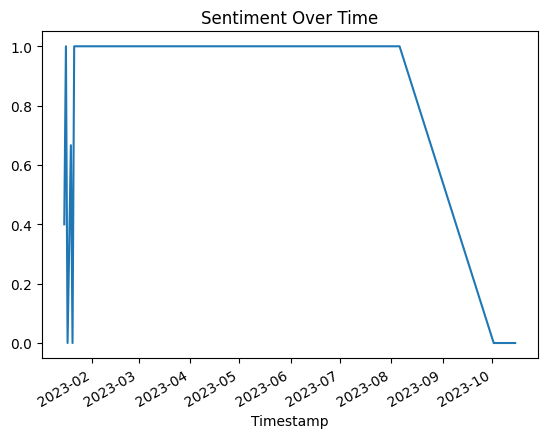

In [18]:
# plot 
plt.figure()
ts.plot(title="Sentiment Over Time")
plt.show()

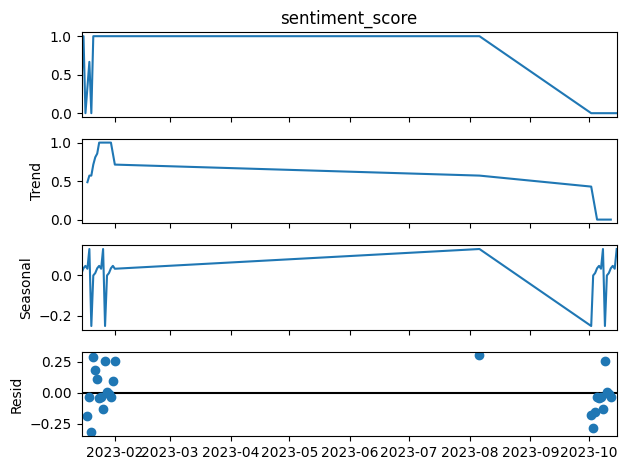

In [19]:
# NOTE: Requires evenly spaced data
decomposition = seasonal_decompose(ts, model='additive', period=7)

decomposition.plot()
plt.show()

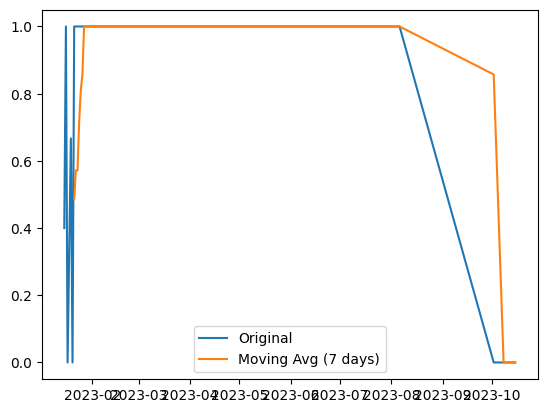

In [20]:
# moving average
ts_ma = ts.rolling(window=7).mean()

plt.figure()
plt.plot(ts, label='Original')
plt.plot(ts_ma, label='Moving Avg (7 days)')
plt.legend()
plt.show()

C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


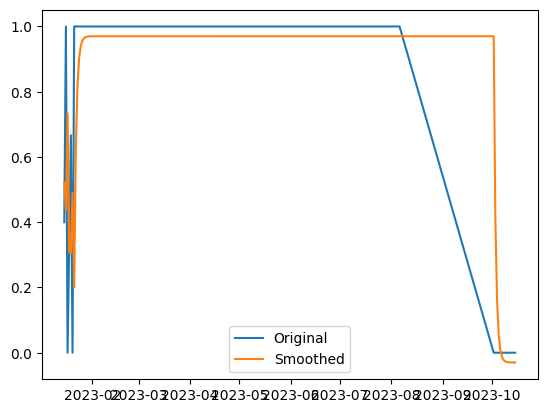

In [21]:
# exponential smoothing
model_es = ExponentialSmoothing(ts, trend='add', seasonal=None)
fit_es = model_es.fit()

ts_es = fit_es.fittedvalues

plt.figure()
plt.plot(ts, label='Original')
plt.plot(ts_es, label='Smoothed')
plt.legend()
plt.show()

In [22]:
# split data
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

# build model
model_arima = ARIMA(train, order=(1,1,1))
fit_arima = model_arima.fit()

# forecast
forecast = fit_arima.forecast(steps=len(test))

C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is availab

In [23]:
# Evaluation (RMSE)
rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)

RMSE: 2.6165780650203813e-05


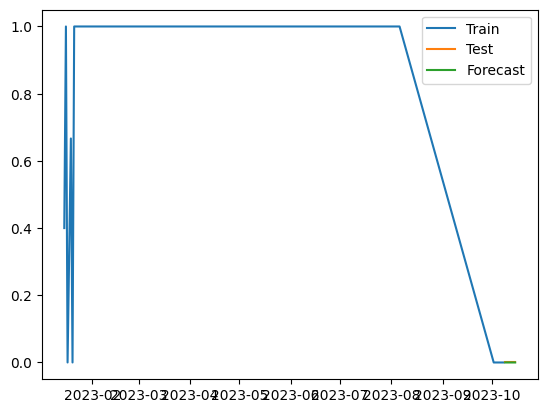

In [24]:
# 📈 Forecast Visualization
plt.figure()
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(test.index, forecast, label='Forecast')
plt.legend()
plt.show()